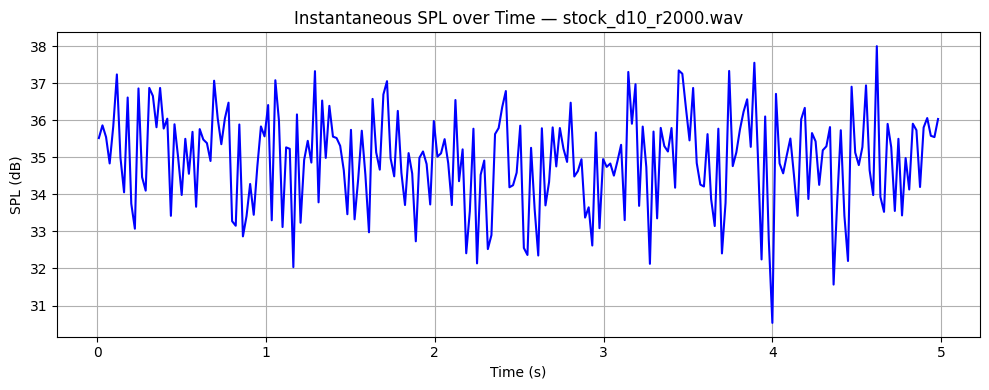

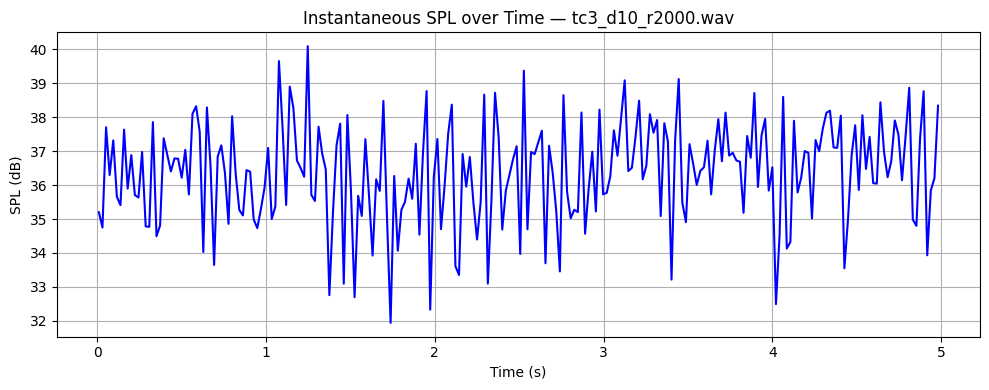

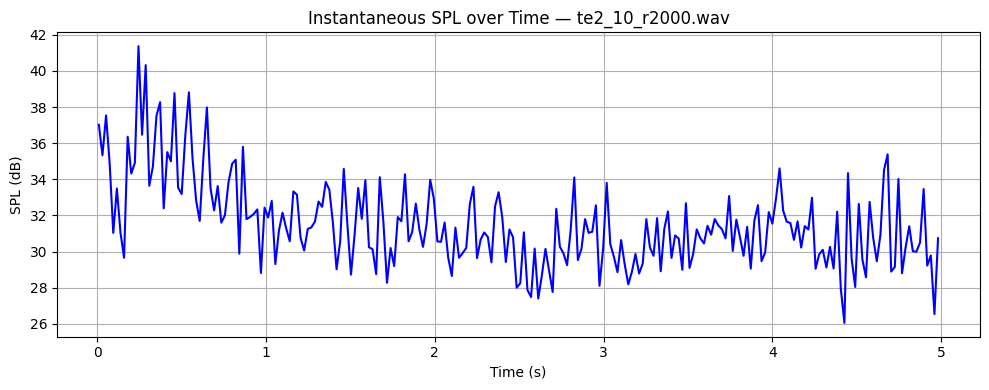

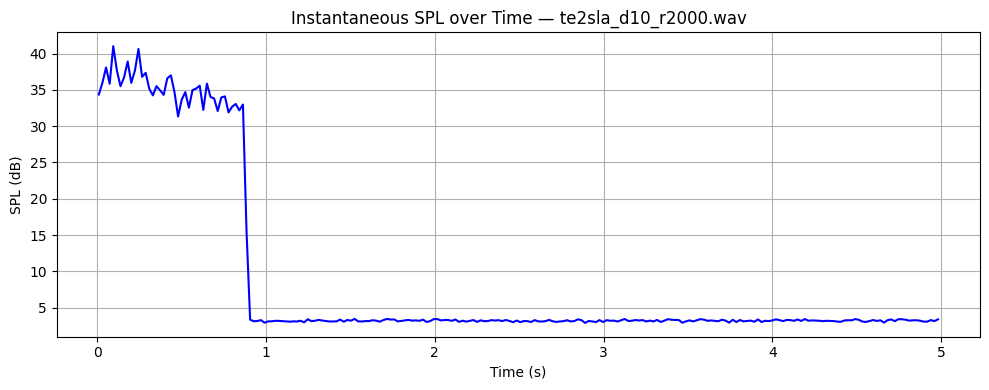

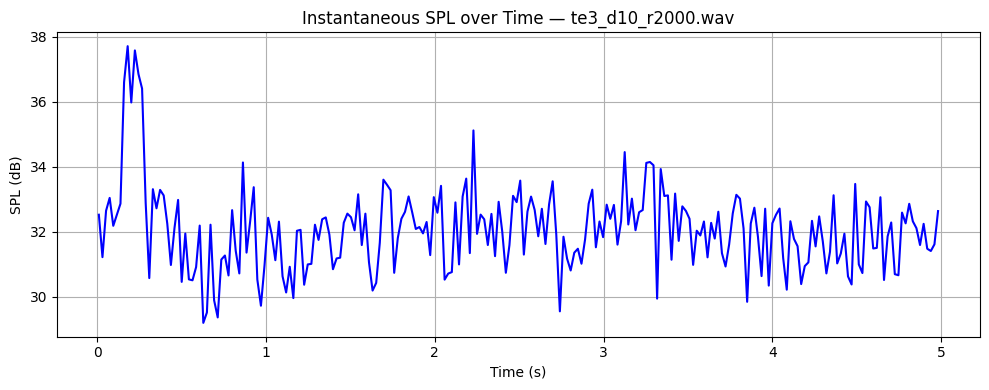

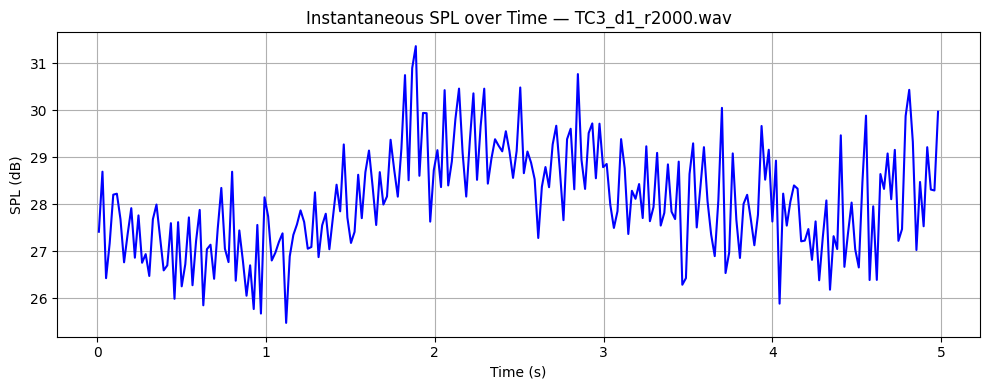

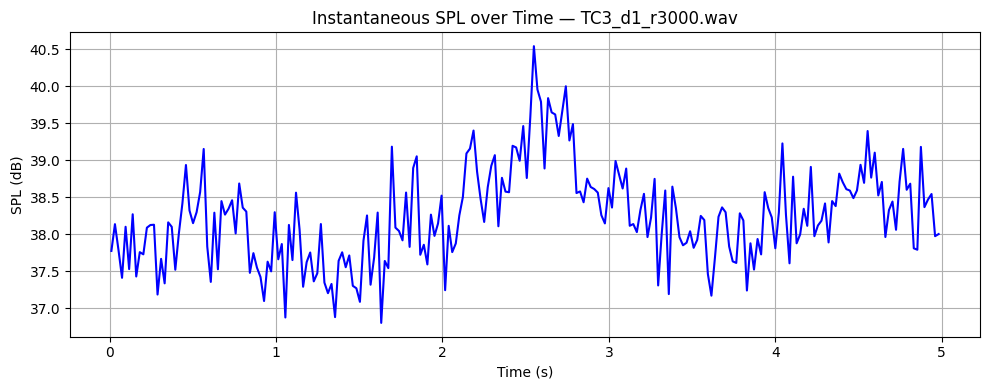

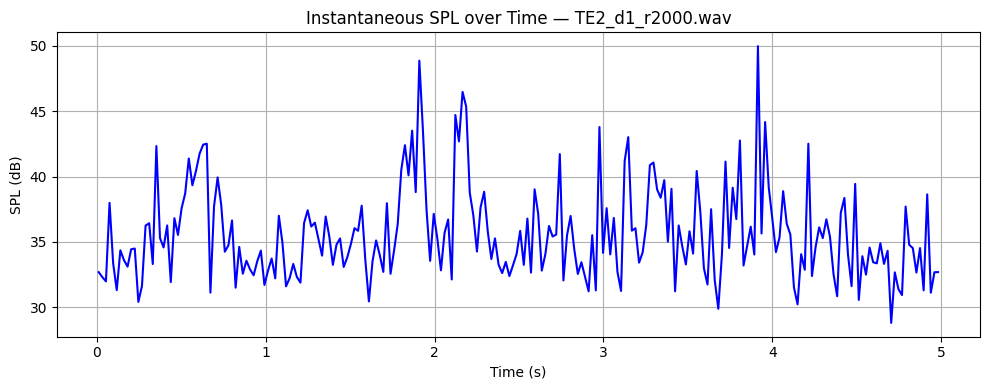

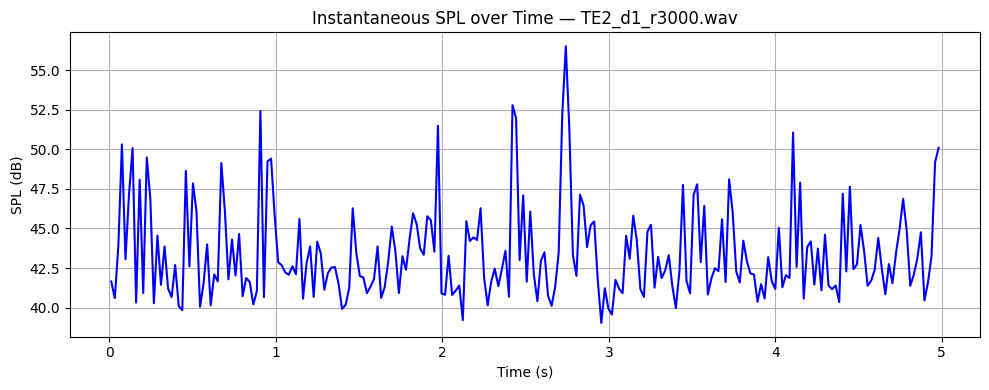

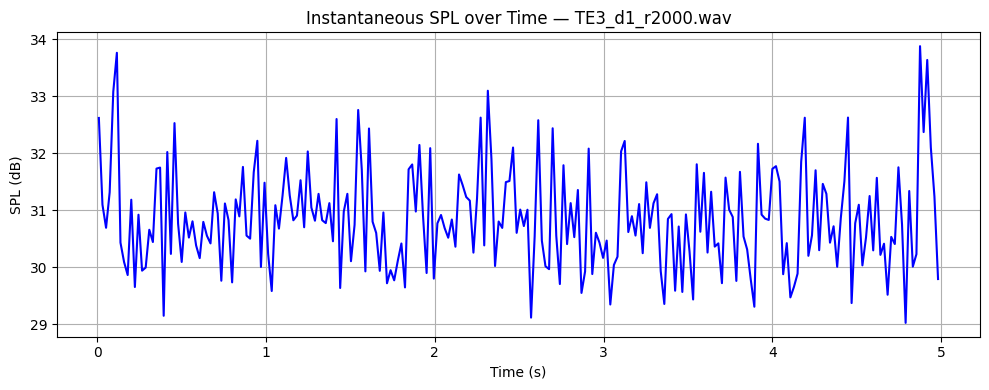

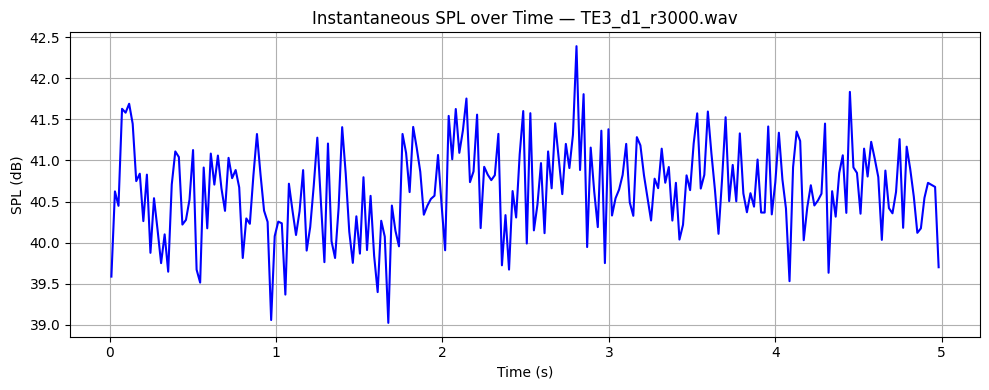

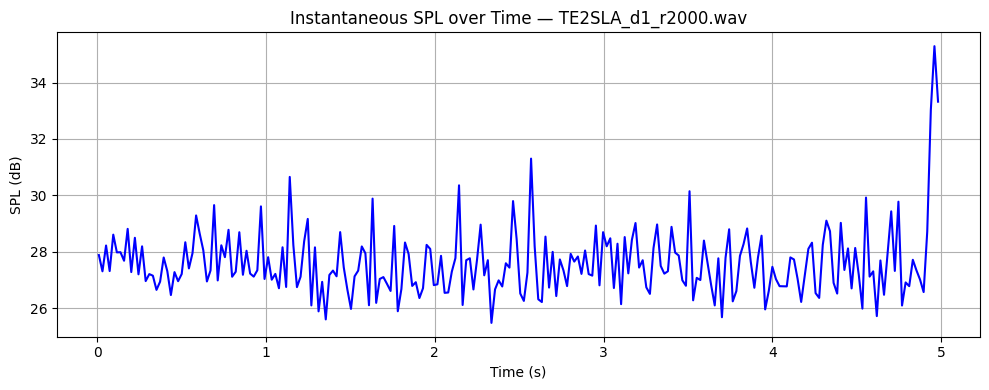

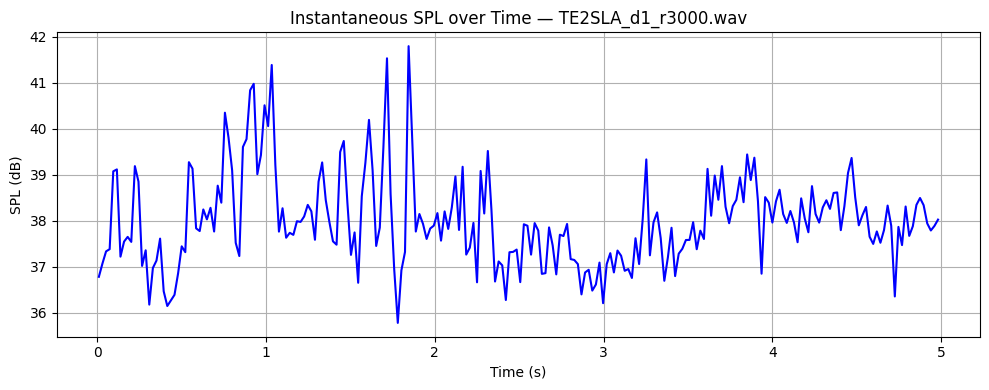

In [26]:
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
import os

# === SPL Conversion ===
def compute_spl_db(pressure, Mul_fac, ref=20e-6):
    """
    Convert pressure signal to SPL in dB using the provided multiplier factor.
    """
    pressure *= Mul_fac  # Apply calibration multiplier
    p_rms = np.sqrt(np.mean(pressure**2))  # Calculate RMS of the pressure signal
    return 20 * np.log10(p_rms / ref + 1e-20)  # Convert RMS to SPL in dB

# === SPL vs Time (windowed) ===
def plot_spl_time(pressure, samplerate, Mul_fac, file_label, window_size=1024, overlap=0):
    step = window_size - overlap  # Step size (for non-overlapping windows)
    n_samples = len(pressure)  # Total samples in the signal
    n_windows = (n_samples - overlap) // step  # Number of windows to process
    
    SPL_series = np.zeros(n_windows)  # Store SPL for each window
    time = np.zeros(n_windows)  # Store the corresponding time for each window
    
    # Compute SPL per window
    for i in range(n_windows):
        idx_start = i * step
        idx_end = idx_start + window_size
        if idx_end > n_samples:
            break
        
        segment = pressure[idx_start:idx_end]  # Get the windowed segment
        segment_mean = np.mean(segment)  # Remove DC offset (mean)
        perturb = segment - segment_mean  # Subtract the mean (perturb the signal)
        
        # Calculate RMS of the windowed segment
        p_rms = np.sqrt(np.mean(perturb**2))
        
        # Calculate SPL for this window and store it
        SPL_series[i] = 20 * np.log10(p_rms / 20e-6)
        
        # Store the time at the center of the window
        time[i] = (idx_start + window_size / 2) / samplerate
    
    # Plot SPL over time
    plt.figure(figsize=(10, 4))
    plt.plot(time, SPL_series, 'b', linewidth=1.5)
    plt.xlabel('Time (s)')
    plt.ylabel('SPL (dB)')
    plt.title(f'Instantaneous SPL over Time — {file_label}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# === Process Each Audio File ===
def process_audio_file(file_path, Mul_fac):
    pressure, samplerate = sf.read(file_path)

    if pressure.ndim > 1:
        pressure = np.mean(pressure, axis=1)  # Convert to mono if stereo

    label = os.path.basename(file_path)

    plot_spl_time(pressure, samplerate, Mul_fac, label)

# === Your Paths ===
Mul_fac = ((10**6.1925)/10**0.0475)*(20e-6)  # Calibration factor as per your method

wav_files = [
    r"/home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/stock_d10_r2000.wav",
    r"/home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/tc3_d10_r2000.wav",
    r"/home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/te2_10_r2000.wav",
    r"/home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/te2sla_d10_r2000.wav",
    r"/home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/te3_d10_r2000.wav",
    r"/home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/New Data/TC3_d1_r2000.wav",
    r"/home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/New Data/TC3_d1_r3000.wav",
    r"/home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/New Data/TE2_d1_r2000.wav",
    r"/home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/New Data/TE2_d1_r3000.wav",
    r"/home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/New Data/TE3_d1_r2000.wav",
    r"/home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/New Data/TE3_d1_r3000.wav",
    r"/home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/New Data/TE2SLA_d1_r2000.wav",
    r"/home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/New Data/TE2SLA_d1_r3000.wav",
]

# === Run ===
for wav_path in wav_files:
    process_audio_file(wav_path, Mul_fac)


In [27]:
import numpy as np
import soundfile as sf

# === SPL Calculation using Calibration Factor ===
def compute_oaspl(pressure, Mul_fac, p_ref=20e-6):
    """
    Compute the Overall SPL (OASPL) using the provided calibration factor.
    """
    # Apply calibration factor to the pressure signal
    pressure *= Mul_fac
    
    # Remove DC offset (mean of the signal)
    pressure_perturbed = pressure - np.mean(pressure)
    
    # Calculate RMS of the entire signal
    p_rms_total = np.sqrt(np.mean(pressure_perturbed**2))
    
    # Calculate OASPL
    oaspl = 20 * np.log10(p_rms_total / p_ref + 1e-20)  # Adding small value to avoid log(0)
    
    return oaspl

# === Process Audio File ===
def process_audio_file(file_path, Mul_fac):
    # Read the audio file
    pressure, samplerate = sf.read(file_path)

    if pressure.ndim > 1:
        pressure = np.mean(pressure, axis=1)  # Convert to mono if stereo
    
    # Compute OASPL
    oaspl = compute_oaspl(pressure, Mul_fac)
    print(f"OASPL for {file_path}: {oaspl:.2f} dB")

# === Your Paths ===
Mul_fac = ((10**6.1925)/10**0.0475)*(20e-6)  # Calibration factor as per your method

wav_files = [
    r"/home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/stock_d10_r2000.wav",
    r"/home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/tc3_d10_r2000.wav",
    r"/home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/te2_10_r2000.wav",
    r"/home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/te2sla_d10_r2000.wav",
    r"/home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/te3_d10_r2000.wav",
    r"/home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/New Data/TC3_d1_r2000.wav",
    r"/home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/New Data/TC3_d1_r3000.wav",
    r"/home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/New Data/TE2_d1_r2000.wav",
    r"/home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/New Data/TE2_d1_r3000.wav",
    r"/home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/New Data/TE3_d1_r2000.wav",
    r"/home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/New Data/TE3_d1_r3000.wav",
    r"/home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/New Data/TE2SLA_d1_r2000.wav",
    r"/home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/New Data/TE2SLA_d1_r3000.wav",
]

# === Run ===
for wav_path in wav_files:
    process_audio_file(wav_path, Mul_fac)


OASPL for /home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/stock_d10_r2000.wav: 64.27 dB
OASPL for /home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/tc3_d10_r2000.wav: 65.73 dB
OASPL for /home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/te2_10_r2000.wav: 63.95 dB
OASPL for /home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/te2sla_d10_r2000.wav: 57.33 dB
OASPL for /home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/te3_d10_r2000.wav: 61.44 dB
OASPL for /home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/New Data/TC3_d1_r2000.wav: 58.60 dB
OASPL for /home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/New Data/TC3_d1_r3000.wav: 67.27 dB
OASPL for /home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/New Data/TE2_d1_r2000.wav: 74.93 dB
OASPL for /home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/New Data/TE2_d1_r3000.wav: 81.00 dB
OASPL for /home/destrox-907/Husnian_FYP/AI_Code Files/hashim data/New Data/TE3_d1_r2000.wav: 60.59 dB
OASPL for /home/